In [1]:
import os
import sys

# 1. Kies je definitieve projectnaam
project_naam = "NLP_LSystem_V3_Final_PRO"

# 2. Maak de folder aan op je computer
if not os.path.exists(project_naam):
    os.makedirs(project_naam)
    print(f"Nieuwe folder '{project_naam}' aangemaakt.")

# 3. GA DE FOLDER IN (Cruciaal voor je data-opslag!)
os.chdir(os.path.abspath(project_naam))

# 4. Maak ook direct de data-submap aan
if not os.path.exists('data'):
    os.makedirs('data')

print(f"Je werkt nu officieel in: {os.getcwd()}")


Nieuwe folder 'NLP_LSystem_V3_Final_PRO' aangemaakt.
Je werkt nu officieel in: c:\Users\Annelies\NLP_LSystem_V3_Final_PRO


Systeem start op...

--- RESULTATEN ---
Eerlijke Hit-Rate (Index -> BTC): 39.81%
Laatste 20 letters BTC: ...cdddddddddcdcbcdcbba


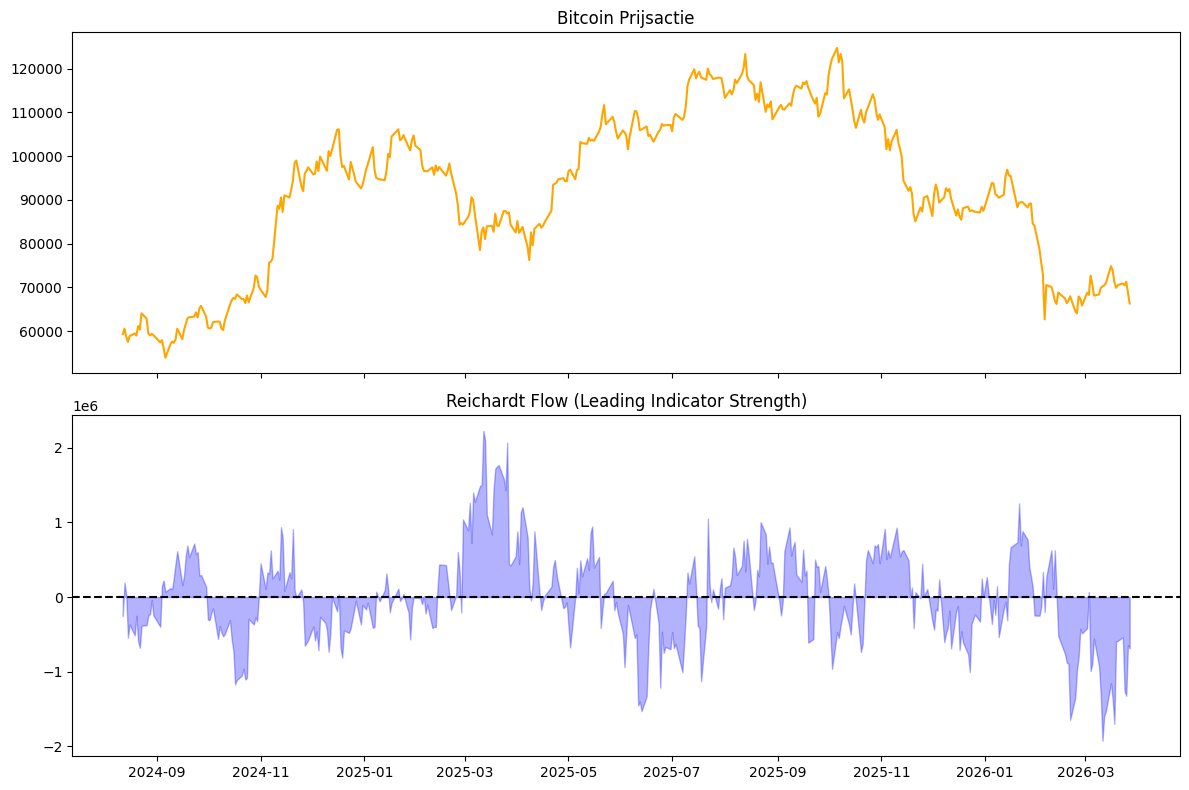

In [2]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP & DATA ---
project_folder = "NLP_LSystem_V3_Final"
if not os.path.exists(project_folder): os.makedirs(project_folder)
os.chdir(project_folder)

def get_market_data():
    tickers = ["^GSPC", "BTC-USD"]
    raw = yf.download(tickers, period="2y", interval="1d", progress=False)['Close']
    df = raw.rename(columns={'^GSPC': 'Index', 'BTC-USD': 'Bitcoin'}).dropna()
    return df

# --- 2. FFD ENGINE (Fractal Memory) ---
def apply_ffd(series, d=0.2, thres=1e-3):
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < thres: break
        w.append(w_k)
        k += 1
    w_array = np.array(w[::-1])
    # Gebruik np.convolve voor stabiliteit
    output = np.convolve(series, w_array, mode='valid')
    return output, len(w_array)

# --- 3. SAX-NLP ENCODER (Adaptieve Grammatica) ---
def to_rolling_sax(arr, rolling_window=20):
    chars = []
    for i in range(rolling_window, len(arr)):
        past_window = arr[i-rolling_window:i]
        bins = np.percentile(past_window, [25, 50, 75])
        val = arr[i]
        if val <= bins[0]: chars.append('d')
        elif val <= bins[1]: chars.append('c')
        elif val <= bins[2]: chars.append('b')
        else: chars.append('a')
    return "".join(chars)

# --- 4. RECURSIVE L-SYSTEM PARSER ---
def run_nlp_analysis(str_idx, str_btc, window=2, lookback=40):
    hits, total = 0, 0
    for i in range(lookback, len(str_idx) - 1):
        gram = {}
        for j in range(i - lookback, i - window):
            motif = str_idx[j:j+window]
            nxt = str_btc[j+window]
            gram[motif] = gram.get(motif, []) + [nxt]
        
        rules = {k: max(set(v), key=v.count) for k, v in gram.items() if v}
        current_motif = str_idx[i-window+1:i+1]
        
        if current_motif in rules:
            if rules[current_motif] == str_btc[i+1]: hits += 1
            total += 1
    return (hits/total * 100) if total > 0 else 0

# --- 5. REICHARDT FLOW ---
def get_rolling_flow(a, b, window=20):
    flows = []
    for i in range(window, len(a)):
        s_a, s_b = a[i-window:i], b[i-window:i]
        flow = np.mean(s_a[:-1] * s_b[1:] - s_a[1:] * s_b[:-1])
        flows.append(flow)
    return np.array(flows)

# --- MAIN EXECUTION ---
print("Systeem start op...")
df = get_market_data()

# Fractale transformatie
fd_index, _ = apply_ffd(df['Index'].values, d=0.2)
fd_btc, _ = apply_ffd(df['Bitcoin'].values, d=0.2)

# Grammatica extractie
s_idx = to_rolling_sax(fd_index)
s_btc = to_rolling_sax(fd_btc)

# Hit-Rate berekening
hr = run_nlp_analysis(s_idx, s_btc)
flow_series = get_rolling_flow(fd_index, fd_btc)

print(f"\n--- RESULTATEN ---")
print(f"Eerlijke Hit-Rate (Index -> BTC): {hr:.2f}%")
print(f"Laatste 20 letters BTC: ...{s_btc[-20:]}")

# Visualisatie
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(df.index[-len(flow_series):], df['Bitcoin'].values[-len(flow_series):], color='orange')
ax1.set_title('Bitcoin Prijsactie')
ax2.fill_between(df.index[-len(flow_series):], flow_series, color='blue', alpha=0.3)
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title('Reichardt Flow (Leading Indicator Strength)')
plt.tight_layout()
plt.show()
